**Loading the dataset: CIFAR-10**

We will use the CIFAR-10 dataset for training and testing (https://www.cs.toronto.edu/~kriz/cifar.html).

In [1]:
# import section
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import Sequential

from sklearn.metrics import confusion_matrix
import seaborn as sns

from tensorflow.keras.callbacks import EarlyStopping

In [2]:
# load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

**Visualize the data**

<Figure size 393.701x393.701 with 0 Axes>

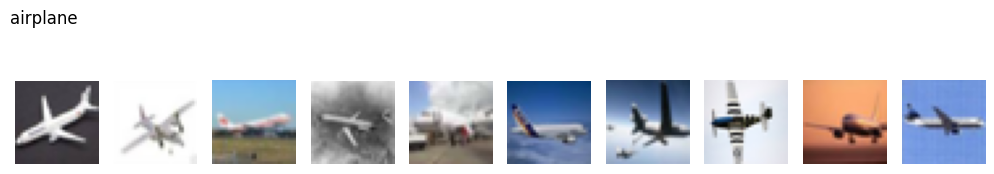

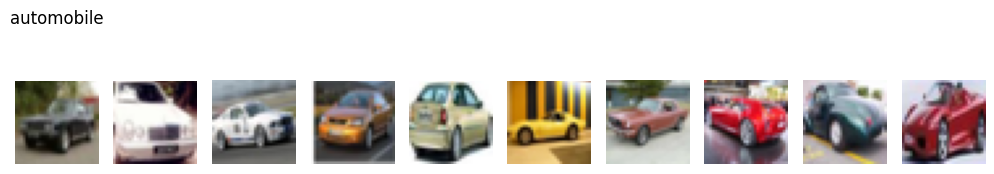

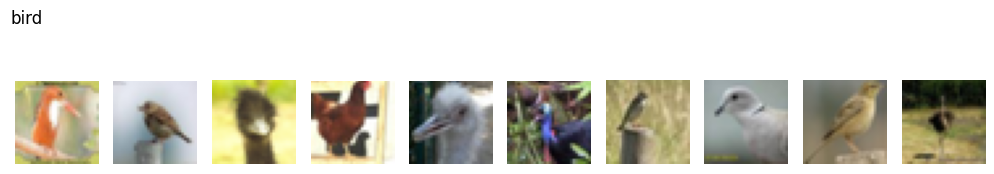

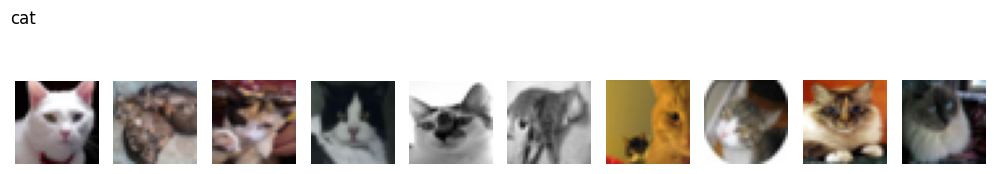

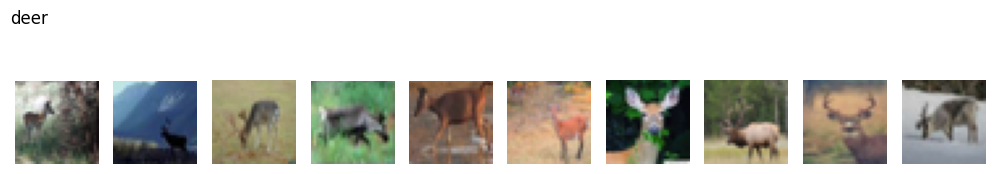

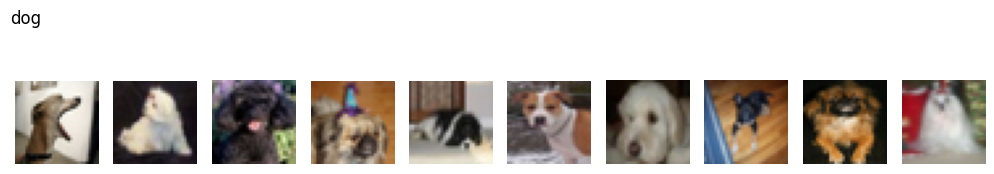

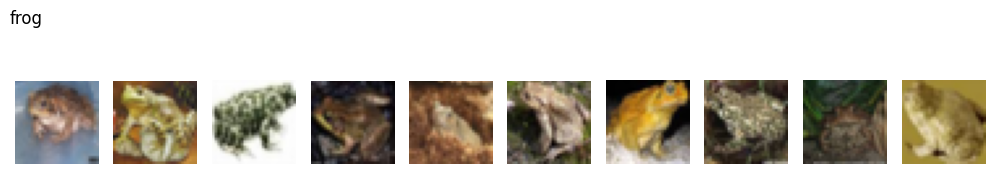

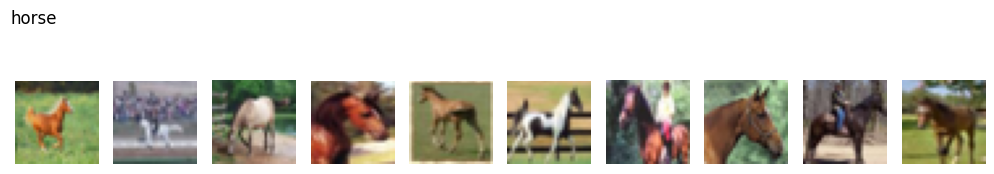

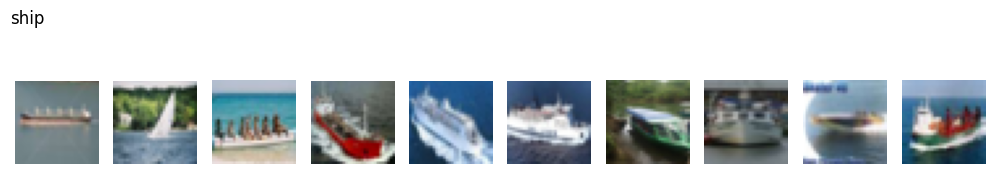

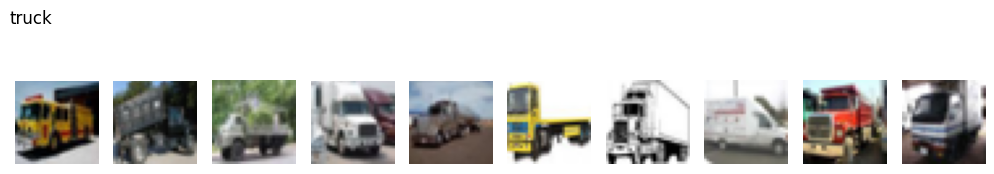

In [3]:
#print(x_train.shape)

# define the classes of the CIFAR-10 dataset
labels = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]

# number of classes of the CIFAR-10 dataset
num_classes = len(labels)

# prepare and display 10 pictures for each class
fig = plt.figure(figsize=(10*1/2.54, 10*1/2.54))

for idx_class in range(num_classes):

  all_idx = np.where(y_train.flatten() == idx_class)[0]

  # random selection of 10 image of each class
  rand_idx = np.random.choice(all_idx, size=10, replace=False)
  selected = x_train[rand_idx]

  plt.figure(figsize=(10, 2))

  # add class label (left side of the row)
  plt.suptitle(f"{labels[idx_class]}", fontsize=12, x=0.01, ha="left")
  #plt.text(-0.1, 0.5, labels[idx_class], fontsize=10, va='center', ha='right', transform=plt.gca().transAxes)

  for i in range(10):
    ax = plt.subplot(1, 10, i+1)
    plt.imshow(selected[i])
    ax.axis("off")

  plt.tight_layout()

  plt.show()

**Data normalization**

In [4]:
x_test_in = x_test

# normalize the data for both x_train and x_test
x_train = x_train.astype("float32") / 255
x_test = x_test.astype("float32") / 255

print(x_train.shape)
print(x_test.shape)

(50000, 32, 32, 3)
(10000, 32, 32, 3)


**Prepare the labels**

In [5]:
y_test_in = y_test

# transform both y_train and y_test to categorical form
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

print(y_train.shape)
print(y_test.shape)

(50000, 10)
(10000, 10)


**Define the model**

In [6]:
input_shape = (32, 32, 3)

#my_reg = keras.regularizers.l2(0.0001)

model1 = Sequential(
    [
        keras.Input(shape=input_shape),

        # data augmentation
        layers.RandomFlip("horizontal"),
        layers.RandomTranslation(0.125, 0.125),

        # block 1
        layers.Conv2D(32, kernel_size=(3,3), padding="same", activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(32, kernel_size=(3,3), padding="same", activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Dropout(0.15),

        # block 2
        layers.Conv2D(64, kernel_size=(3,3), padding="same", activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(64, kernel_size=(3,3), padding="same", activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Dropout(0.20),

        # block 3
        layers.Conv2D(128, kernel_size=(3,3), padding="same", activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(128, kernel_size=(3,3), padding="same", activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Dropout(0.30),

        # block 4
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.40),

        layers.Dense(num_classes, activation="softmax")
    ]
)

# show details of the model
model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation              │ (None, 32, 32, 3)      │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 816,938 (3.12 MB)

 Trainable params: 815,530 (3.11 MB)

 Non-trainable params: 1,408 (5.50 KB)

**Compile the model**

In [7]:
import time

#my_SGD = keras.optimizers.SGD(learning_rate=0.001)
#my_Adam = keras.optimizers.Adam(learning_rate=0.005)
#my_SGD = keras.optimizers.SGD(learning_rate=0.01, momentum=0.9, nesterov=True)

# early stop
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# compile the model with Adap optimizer
model1.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
#model1.compile(loss='categorical_crossentropy', optimizer=my_SGD, metrics=['accuracy'])

# fit the model; measure the fit time
start = time.time()
history = model1.fit(x_train, y_train, batch_size=512, epochs=100, validation_split=0.1, callbacks=[early_stop])
end = time.time()

# display the fit time
total_time = end - start
print("Training time:", total_time, "seconds")

# display the average fit time per epoch
epochs = len(history.history['loss'])
avg_time = total_time / epochs
print("Average time per epoch:", avg_time, "seconds")

Epoch 1/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 20s 119ms/step - accuracy: 0.2987 - loss: 2.3102 - val_accuracy: 0.1000 - val_loss: 2.8478
Epoch 2/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 8s 93ms/step - accuracy: 0.4751 - loss: 1.4943 - val_accuracy: 0.1380 - val_loss: 3.0060
Epoch 3/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 8s 92ms/step - accuracy: 0.5612 - loss: 1.2313 - val_accuracy: 0.1620 - val_loss: 2.9512
Epoch 4/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 8s 93ms/step - accuracy: 0.6051 - loss: 1.0921 - val_accuracy: 0.2324 - val_loss: 2.6336
Epoch 5/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 8s 93ms/step - accuracy: 0.6531 - loss: 0.9807 - val_accuracy: 0.3958 - val_loss: 1.7106
Epoch 6/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 8s 94ms/step - accuracy: 0.6837 - loss: 0.8962 - val_accuracy: 0.6858 - val_loss: 0.8839
Epoch 7/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 8s 94ms/step - accuracy: 0.6993 - loss: 0.8433 - val_accuracy: 0.7128 - val_loss: 0.8318
Epoch 8/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 8s 94ms/step - accuracy: 0.7135 - loss: 0.8041 - val_accuracy: 

In [8]:
# display the accuracies for the train and validation sets
print(history.history.keys())

print("Train accuracy:", history.history["accuracy"][-1])
print("Validation accuracy:", history.history["val_accuracy"][-1])

# display the losses for the train and validation sets

print("Train loss:", history.history["loss"][-1])
print("Validation loss:", history.history["val_loss"][-1])

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])
Train accuracy: 0.8490222096443176
Validation accuracy: 0.8428000211715698
Train loss: 0.43779462575912476
Validation loss: 0.46396884322166443


**Evaluate the model**

Test accuracy: 0.8367000222206116
Test loss: 0.49145033955574036
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


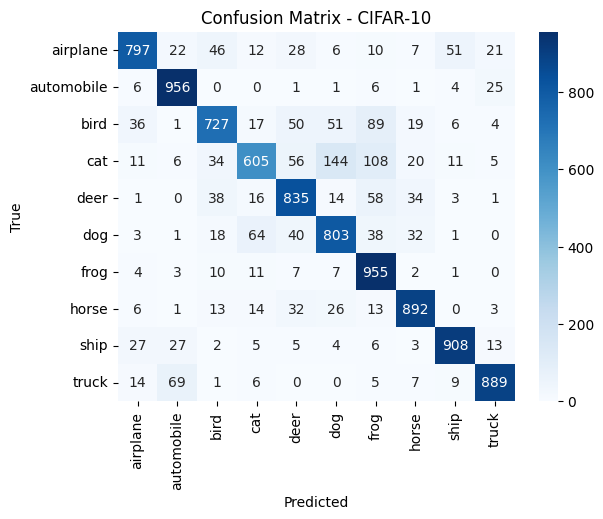

In [9]:
# evaluate the model and print the test accuracy and loss
score = model1.evaluate(x_test, y_test, verbose=0)
print("Test accuracy:", score[1])
print("Test loss:", score[0])

# prepare and display the confusion matrix for the testing set
y_test_pred_prob = model1.predict(x_test)
y_test_pred = y_test_pred_prob.argmax(axis=1)

conf_matr = confusion_matrix(y_test.argmax(axis=1), y_test_pred)

sns.heatmap(conf_matr, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - CIFAR-10")
plt.show()

**Check the pictures that were wrongly categorized**

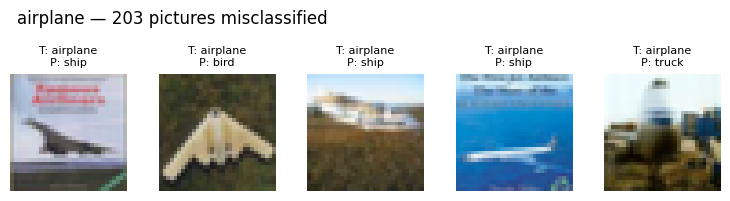

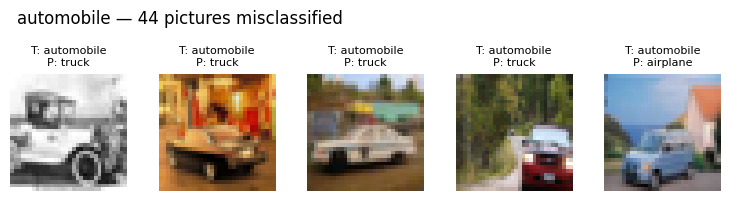

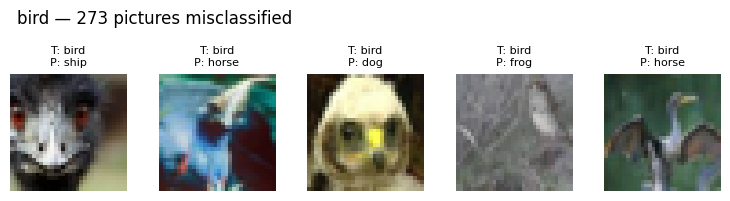

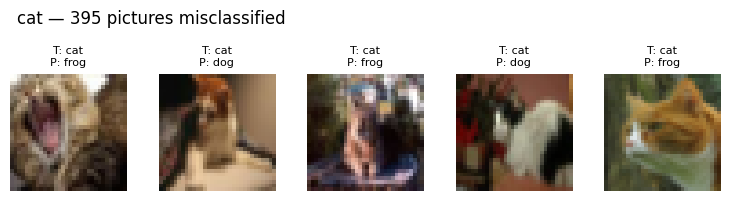

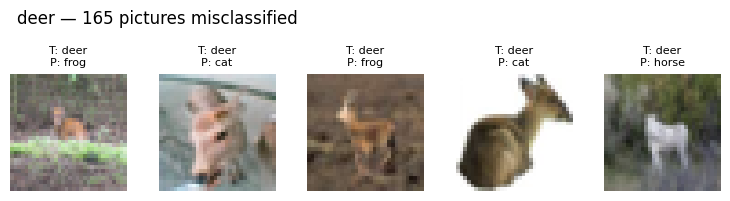

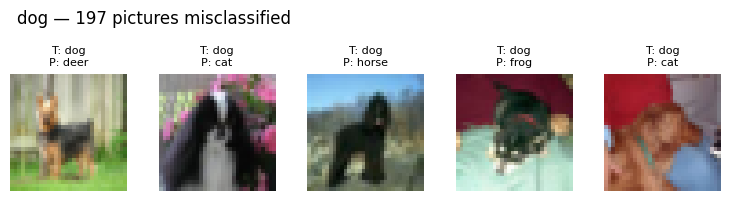

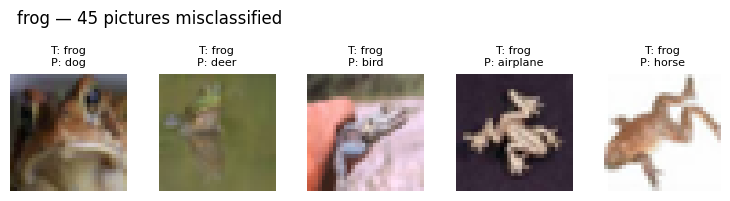

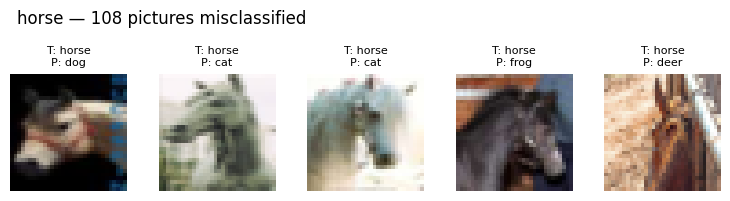

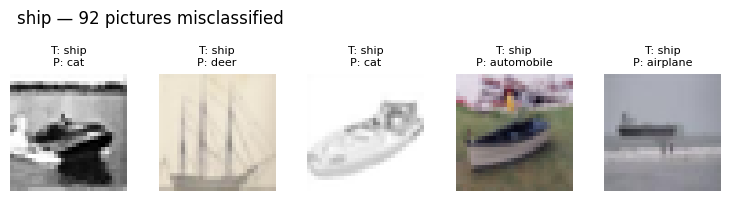

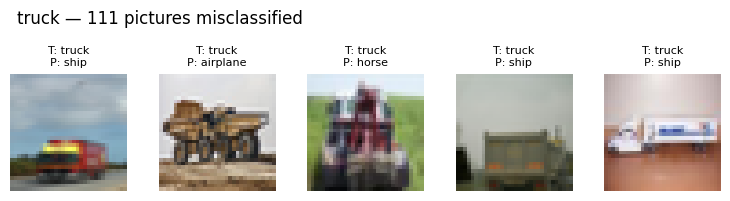

In [10]:
# the number of wrong predicted photos per class to be displayed
max_per_class = 5

# check the positions where the predictions were wrong
y_test_in_r = y_test_in.ravel()
idx_diff = np.where(y_test_pred != y_test_in_r)[0]

# separate the wrongly predicted idx per classes
diff_by_class = {i: [] for i in range(len(labels))}
for idx in idx_diff:
  true_label = y_test_in_r[idx]
  diff_by_class[true_label].append(idx)

for class_id, class_name in enumerate(labels):
  idx_list = diff_by_class[class_id]
  if len(idx_list) == 0:
    continue

  # display a maximum number of missclassified photos per class (5)
  n = len(idx_list)
  idx_list = idx_list[:max_per_class]
  cols = num_classes
  rows = 1
  plt.figure(figsize=(cols * 1.5, 2))
  plt.suptitle(f"{class_name} — {n} pictures misclassified", fontsize=12, x=0.02, ha="left")

  for i, idx in enumerate(idx_list):
    plt.subplot(rows, cols, i + 1)
    plt.imshow(x_test[idx])
    plt.axis("off")
    pred_label = labels[y_test_pred[idx]]
    plt.title(f"T: {class_name}\nP: {pred_label}", fontsize=8)

  plt.tight_layout(rect=[0, 0, 1, 0.9])
  plt.show()


**Save the model to file**

In [11]:
import os

#print("Working directory:", os.getcwd())
#print("Files here:", os.listdir())

# save the trained model
model1.save("cifar10.model14_2.keras")